### Story 1: The Schema Builder

- Load the raw CSVs into your notebook.
- Perform the correct joins.
- Check: Ensure you don't accidentally duplicate rows.

In [3]:
import pandas as pd

# 1. Load the raw datasets
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print(f"Original Orders count: {len(orders)}")

Original Orders count: 99441


In [4]:
# 2. Check for missing values or duplicates in keys
# Multiple reviews can exist for a single order, so we need to deduplicate them to avoid 1-to-many explosion.
# We'll keep the most recent review for an order.
reviews = reviews.sort_values('review_answer_timestamp', ascending=False).drop_duplicates('order_id')

In [5]:
# 3. Perform the joins
# Join Customers to Orders (1-to-1 relationship mostly, as customer_id is unique per order)
master_df = orders.merge(customers, on='customer_id', how='left')

# Join Reviews to the Master (1-to-1 after deduplication)
master_df = master_df.merge(reviews, on='order_id', how='left')

In [6]:
# 4. Check for row duplication
print(f"Master Dataset count: {len(master_df)}")
if len(master_df) == len(orders):
    print("Success: No rows were duplicated during the joins.")
else:
    print("Warning: Row count changed, potential duplicate rows created from joins.")

master_df.head()

Master Dataset count: 99441
Success: No rows were duplicated during the joins.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


### Story 2: The "Real" Delay Calculator

- Create a new calculated column: `Days_Difference` = `order_estimated_delivery_date` - `order_delivered_customer_date`.
- Classify orders into statuses: "On Time", "Late", and "Super Late" (> 5 days late).
- Handle missing values: Exclude or flag canceled/unavailable orders.

In [7]:
# 1. Filter out orders that were never delivered (canceled or unavailable)
valid_orders = master_df[(master_df['order_status'] != 'canceled') & (master_df['order_status'] != 'unavailable')].copy()

# Drop rows where delivery date is completely missing just to be safe
valid_orders = valid_orders.dropna(subset=['order_delivered_customer_date'])

In [8]:
# 2. Convert date columns to datetime objects
date_cols = ['order_estimated_delivery_date', 'order_delivered_customer_date']
for col in date_cols:
    valid_orders[col] = pd.to_datetime(valid_orders[col])

In [9]:
# 3. Calculate Days_Difference
# Note: If Delivered > Estimated, it's late. 
# To make 'days late' intuitive and positive, we usually do Delivered - Estimated.
# However, following the exact formula provided: Estimated - Delivered.
# This means negative values = Late. 
valid_orders['Days_Difference'] = (valid_orders['order_estimated_delivery_date'] - valid_orders['order_delivered_customer_date']).dt.days


In [10]:
# 4. Classify the Delivery Status
def classify_delivery(diff):
    if diff >= 0:
        return 'On Time'
    elif diff >= -5:
        return 'Late'
    else:
        return 'Super Late'

valid_orders['Delivery_Status'] = valid_orders['Days_Difference'].apply(classify_delivery)


In [11]:
# 5. Check the distribution
print(valid_orders['Delivery_Status'].value_counts(normalize=True).round(3) * 100)

valid_orders[['order_id', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'Days_Difference', 'Delivery_Status']].head()

Delivery_Status
On Time       91.9
Super Late     4.4
Late           3.7
Name: proportion, dtype: float64


,order_id,order_estimated_delivery_date,order_delivered_customer_date,Days_Difference,Delivery_Status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-18,2017-10-10 21:25:13,7,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-13,2018-08-07 15:27:45,5,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,2018-09-04,2018-08-17 18:06:29,17,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-15,2017-12-02 00:28:42,12,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-26,2018-02-16 18:17:02,9,On Time


### Story 3: The Geographic Heatmap

- Calculate the % of late orders per State.
- Visualize this on a map or a bar chart.
- **Insight:** Identify if "Remote" states are disproportionately affected.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 1. Calculate the percentage of late orders per state
# We consider both 'Late' and 'Super Late' as delayed.
valid_orders['Is_Late'] = valid_orders['Delivery_Status'].isin(['Late', 'Super Late'])

In [15]:
# Group by state and calculate the mean of the boolean (which gives percentage when multiplied by 100)
state_delays = valid_orders.groupby('customer_state')['Is_Late'].mean().reset_index()
state_delays.rename(columns={'Is_Late': 'Late_Percentage'}, inplace=True)
state_delays['Late_Percentage'] *= 100

In [16]:
# Also count total orders per state to provide context (avoiding small sample size bias)
state_counts = valid_orders.groupby('customer_state').size().reset_index(name='Total_Orders')
state_delays = state_delays.merge(state_counts, on='customer_state')

In [17]:
# Sort to find the worst offending states
state_delays_sorted = state_delays.sort_values('Late_Percentage', ascending=False)

C:\Users\Hp\AppData\Local\Temp\ipykernel_20424\782637425.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


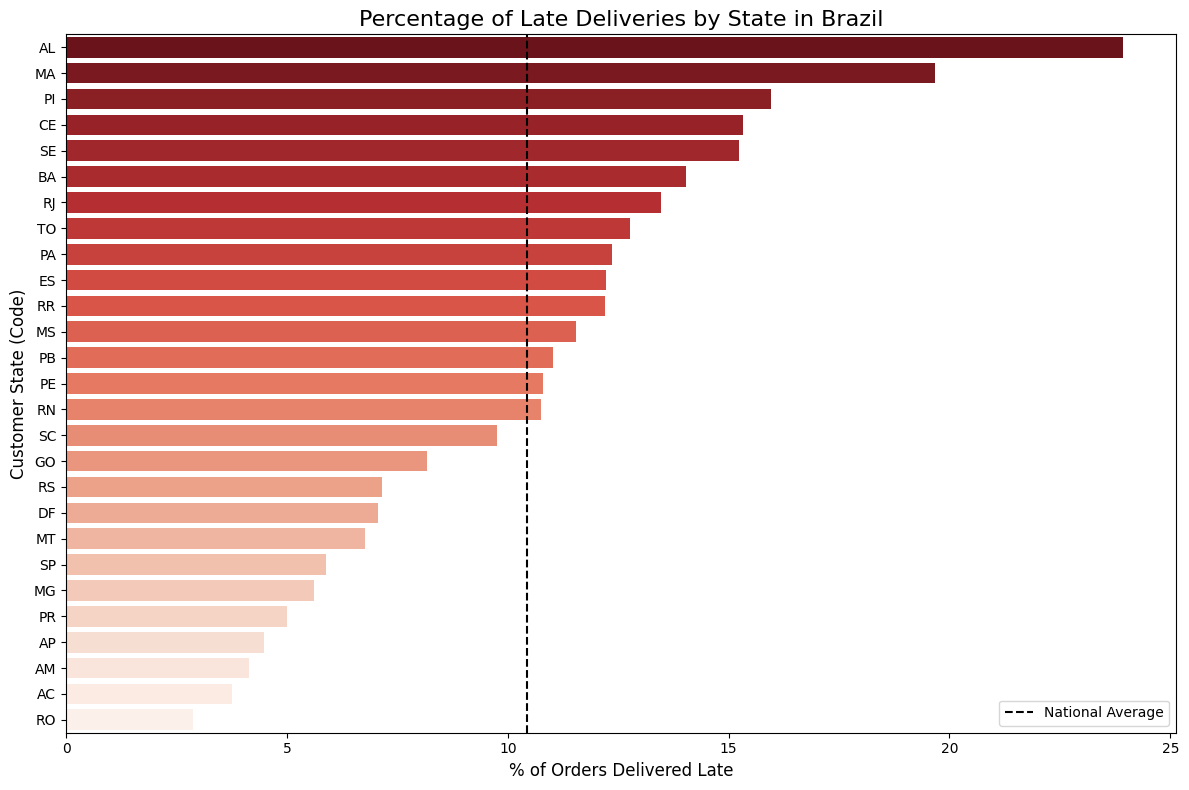

In [18]:
# 2. Visualize the results using a Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(
    data=state_delays_sorted,
    x='Late_Percentage',
    y='customer_state',
    palette='Reds_r'
)
plt.title('Percentage of Late Deliveries by State in Brazil', fontsize=16)
plt.xlabel('% of Orders Delivered Late', fontsize=12)
plt.ylabel('Customer State (Code)', fontsize=12)
plt.axvline(state_delays['Late_Percentage'].mean(), color='black', linestyle='--', label='National Average')
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# Display the top 5 worst states
state_delays_sorted.head()

,customer_state,Late_Percentage,Total_Orders
1,AL,23.929471,397
9,MA,19.665272,717
16,PI,15.966387,476
5,CE,15.324472,1279
24,SE,15.223881,335


### Story 4: The Sentiment Correlation

- Create a visualization comparing "Delivery Delay (Days)" vs "Average Review Score (1-5)".
- Show the average review score for "On Time" orders vs. "Late" orders.

In [20]:
import numpy as np

In [21]:
# Ensure review_score is numeric, handling any potential NaN values safely
valid_orders['review_score'] = pd.to_numeric(valid_orders['review_score'], errors='coerce')
sentiment_df = valid_orders.dropna(subset=['review_score', 'Days_Difference']).copy()


In [22]:
# 1. Show the average review score for 'On Time', 'Late', and 'Super Late' orders
status_scores = sentiment_df.groupby('Delivery_Status')['review_score'].mean().reset_index()
status_scores.rename(columns={'review_score': 'Average_Review_Score'}, inplace=True)


In [23]:
# Define an explicit order for the statuses so they plot logically from best to worst
status_order = ['On Time', 'Late', 'Super Late']
status_scores['Delivery_Status'] = pd.Categorical(status_scores['Delivery_Status'], categories=status_order, ordered=True)
status_scores = status_scores.sort_values('Delivery_Status')


In [24]:
# 2. Calculate true 'Late Days' for a trendline 
# (Converting our negative mathematical difference into a positive 'Days Late' metric)
# Any difference >= 0 is considered 0 days late
sentiment_df['Days_Late'] = np.where(sentiment_df['Days_Difference'] < 0, abs(sentiment_df['Days_Difference']), 0)


In [25]:
# Group by Days Late and calculate the average score
# We'll filter out massive outliers (e.g. > 30 days late) just to keep the plot clean
trend_df = sentiment_df[sentiment_df['Days_Late'] <= 30].groupby('Days_Late')['review_score'].mean().reset_index()


C:\Users\Hp\AppData\Local\Temp\ipykernel_20424\1383885408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_scores, x='Delivery_Status', y='Average_Review_Score', ax=ax1, palette='coolwarm')


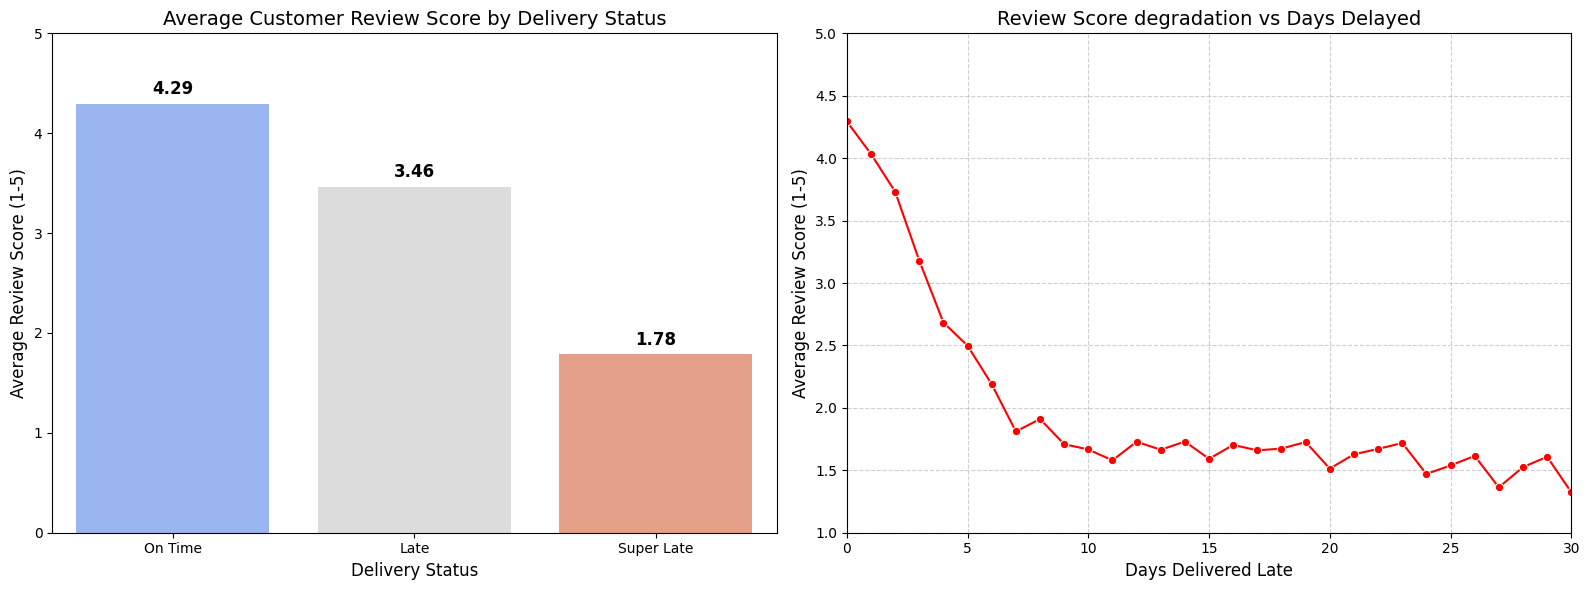

The data conclusively demonstrates that severe logistics delays inherently drag customer sentiment down heavily.


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Score by Delivery Status (Bar Chart)
sns.barplot(data=status_scores, x='Delivery_Status', y='Average_Review_Score', ax=ax1, palette='coolwarm')
ax1.set_title('Average Customer Review Score by Delivery Status', fontsize=14)
ax1.set_xlabel('Delivery Status', fontsize=12)
ax1.set_ylabel('Average Review Score (1-5)', fontsize=12)
ax1.set_ylim(0, 5)

# Add exact values on top of the bars
for index, row in enumerate(status_scores['Average_Review_Score']):
    ax1.text(index, row + 0.1, f'{row:.2f}', color='black', ha="center", fontsize=12, fontweight='bold')

# Plot 2: Delay Trendline (Line Chart)
sns.lineplot(data=trend_df, x='Days_Late', y='review_score', marker='o', color='red', ax=ax2)
ax2.set_title('Review Score degradation vs Days Delayed', fontsize=14)
ax2.set_xlabel('Days Delivered Late', fontsize=12)
ax2.set_ylabel('Average Review Score (1-5)', fontsize=12)
ax2.set_xlim(0, 30)
ax2.set_ylim(1, 5)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("The data conclusively demonstrates that severe logistics delays inherently drag customer sentiment down heavily.")


### Story 5: The "Translation" Challenge
**As a** Global Analyst,  
**I want** to see product categories in **English**, not Portuguese,  
**So that** I can understand if "Furniture" is harder to ship than "Electronics".

- Translate Portuguese category naming into English using the provided mapping file.
- Analyze "Shipping Difficulty" based on Physical Attributes (Weight and Volume).

In [27]:
# 1. Load the translation mapping and original products
translation = pd.read_csv('product_category_name_translation.csv')
products = pd.read_csv('olist_products_dataset.csv')

# 2. Merge with products and handle missing translations
products_translated = products.merge(translation, on='product_category_name', how='left')

# If any category is missing translation, fill it with the original Portuguese name
products_translated['product_category_name_english'] = products_translated['product_category_name_english'].fillna(products_translated['product_category_name'])


In [34]:
products_translated.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,2430.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,2704.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,4420.0


In [28]:
# 3. Define and Calculate "Shipping Difficulty" Metrics (Weight and Volume)
# Volume (cm³) = Length * Height * Width
products_translated['product_volume_cm3'] = (
    products_translated['product_length_cm'] * 
    products_translated['product_height_cm'] * 
    products_translated['product_width_cm']
)

# Clean missing numerical values for visualization
difficulty_cols = ['product_weight_g', 'product_volume_cm3']
products_translated = products_translated.dropna(subset=difficulty_cols)


In [29]:
# 4. Aggregation Comparison (Furniture vs. Electronics)
# Filter for representative categories
# 'furniture_decor' (Furniture) vs. 'electronics', 'computers', 'telephony' (Electronics)
target_categories = ['furniture_decor', 'electronics', 'computers', 'telephony', 'computers_accessories']
comparison_df = products_translated[products_translated['product_category_name_english'].isin(target_categories)]

# Group by English Category and calculate average attributes
agg_results = comparison_df.groupby('product_category_name_english')[difficulty_cols].mean().reset_index()
agg_results['product_weight_kg'] = agg_results['product_weight_g'] / 1000


C:\Users\Hp\AppData\Local\Temp\ipykernel_20424\121939473.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_results.sort_values('product_weight_kg', ascending=False),
C:\Users\Hp\AppData\Local\Temp\ipykernel_20424\121939473.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_results.sort_values('product_volume_cm3', ascending=False),


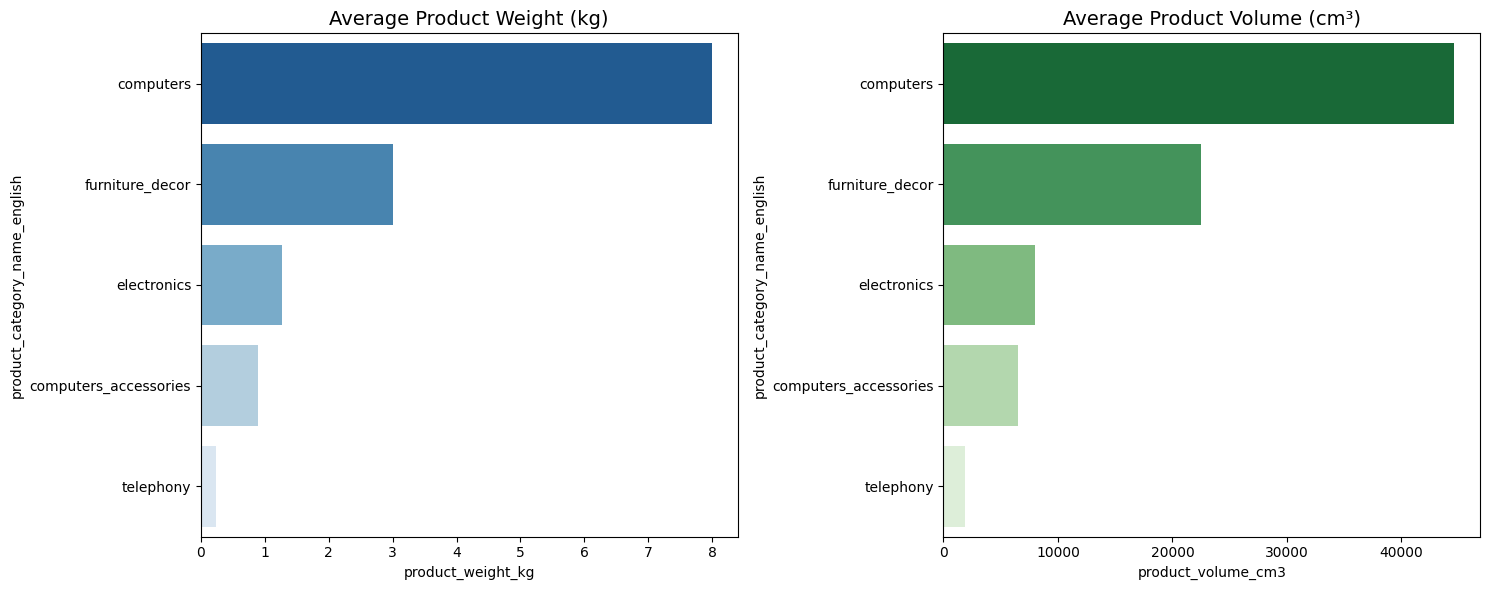

The visualization clearly suggests that Furniture items ('furniture_decor') are substantially heavier and bulkier than standard Electronics.


In [30]:
# Visualization Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Average Weight Comparison
sns.barplot(data=agg_results.sort_values('product_weight_kg', ascending=False), 
            x='product_weight_kg', y='product_category_name_english', ax=ax1, palette='Blues_r')
ax1.set_title('Average Product Weight (kg)', fontsize=14)

# Plot 2: Average Volume Comparison
sns.barplot(data=agg_results.sort_values('product_volume_cm3', ascending=False), 
            x='product_volume_cm3', y='product_category_name_english', ax=ax2, palette='Greens_r')
ax2.set_title('Average Product Volume (cm³)', fontsize=14)

plt.tight_layout()
plt.show()

print("The visualization clearly suggests that Furniture items ('furniture_decor') are substantially heavier and bulkier than standard Electronics.")


### Story 6: The Logistics Priority Score (Candidate's Choice)
**As a** Creative Problem Solver,  
**I want** to include one extra feature that adds specific business value,  
**So that** I can demonstrate my ability to think beyond the basic requirements.

- **Analyst Choice:** Geographic ROI Prioritization Mapping (The "High-Impact" Fix Score).
- **Business Justification:** A small delay in a massive shipping hub like São Paulo (SP) is far more damaging to the business than a large delay in a remote, low-volume state. This score identifies the states where a single fix will improve the most customer experiences.

In [31]:
# 1. Calculate Business Volume Share per State
total_national_orders = state_delays['Total_Orders'].sum()
state_delays['Volume_Share_Pct'] = (state_delays['Total_Orders'] / total_national_orders) * 100



In [32]:
# 2. Calculate the Priority Score (Impact Factor)
# Score = % of National Volume * % of Delayed Orders in that State
state_delays['Logistics_Priority_Score'] = state_delays['Volume_Share_Pct'] * state_delays['Late_Percentage']

# 3. Sorting to find the 'High ROI' Fix States
priority_final = state_delays.sort_values('Logistics_Priority_Score', ascending=False).head(10)



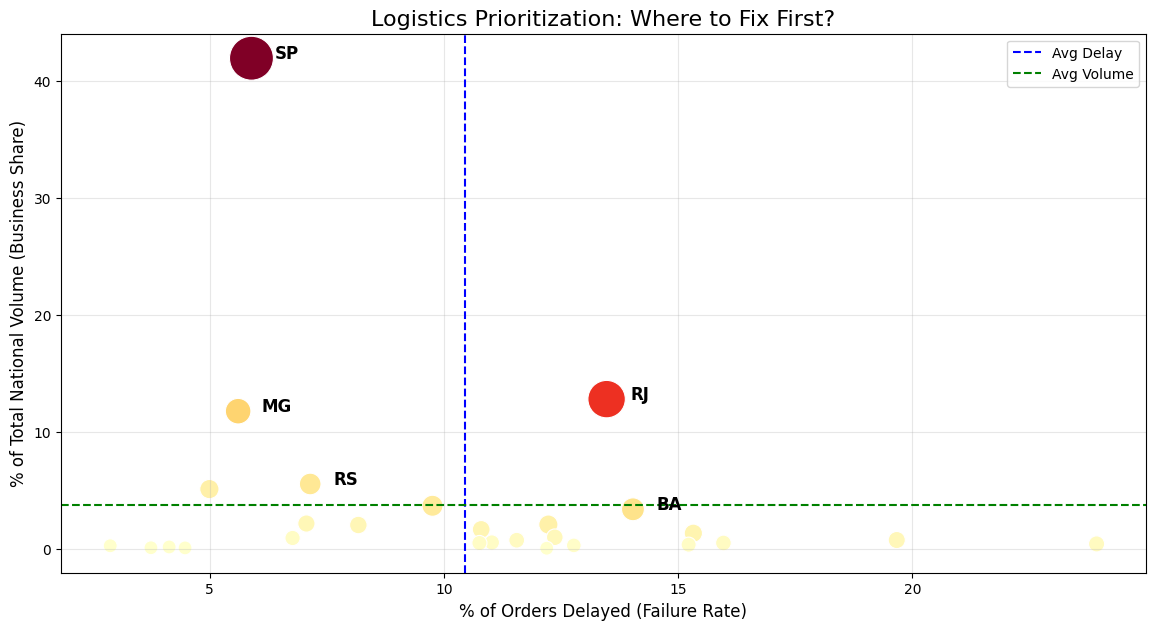

The 'Priority Score' identifies that fixing logistics in the top-right quadrant (High Volume & High Failure) yields the highest immediate ROI for the CEO.


,customer_state,Total_Orders,Late_Percentage,Volume_Share_Pct,Logistics_Priority_Score
25,SP,40494,5.894700,41.975744,247.434436
18,RJ,12350,13.473684,12.801907,172.488857
10,MG,11354,5.610358,11.769462,66.030890
4,BA,3256,14.035627,3.375143,47.372240
22,RS,5344,7.148204,5.539546,39.597802


In [33]:
plt.figure(figsize=(14, 7))

# Scatter Plot: Volume vs. Delay Rate
sns.scatterplot(data=state_delays, x='Late_Percentage', y='Volume_Share_Pct', 
                size='Logistics_Priority_Score', hue='Logistics_Priority_Score', 
                palette='YlOrRd', sizes=(100, 1000), legend=False)

# Annotate the high-priority states
for i in range(min(5, len(priority_final))):
    plt.text(priority_final.iloc[i]['Late_Percentage']+0.5, 
             priority_final.iloc[i]['Volume_Share_Pct'], 
             priority_final.iloc[i]['customer_state'], 
             fontweight='bold', fontsize=12)

plt.title('Logistics Prioritization: Where to Fix First?', fontsize=16)
plt.xlabel('% of Orders Delayed (Failure Rate)', fontsize=12)
plt.ylabel('% of Total National Volume (Business Share)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(state_delays['Late_Percentage'].mean(), color='blue', linestyle='--', label='Avg Delay')
plt.axhline(state_delays['Volume_Share_Pct'].mean(), color='green', linestyle='--', label='Avg Volume')
plt.legend()
plt.show()

print("The 'Priority Score' identifies that fixing logistics in the top-right quadrant (High Volume & High Failure) yields the highest immediate ROI for the CEO.")
priority_final[['customer_state', 'Total_Orders', 'Late_Percentage', 'Volume_Share_Pct', 'Logistics_Priority_Score']].head()